# Parkinson’s Disease Classification using Supervised Machine Learning
### Author: Divya Verma
### Course: BINF5125
### Assignment: Classification Modeling


## Description of data
- **Downloaded from:**

https://www.kaggle.com/datasets/rabieelkharoua/parkinsons-disease-dataset-analysis?resource=download

**Lifestyle Factors**: 

- BMI: Body Mass Index of the patients, ranging from 15 to 40.

- Smoking: Smoking status, where 0 indicates No and 1 indicates Yes.(already a ordinal/binary variable)

- AlcoholConsumption: Weekly alcohol consumption in units, ranging from 0 to 20.

- PhysicalActivity: Weekly physical activity in hours, ranging from 0 to 10.

- DietQuality: Diet quality score, ranging from 0 to 10.

- SleepQuality: Sleep quality score, ranging from 4 to 10.



  **Clinical Measurements:** 

- SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.

- DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.

- CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.

- CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.

- CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.

- CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.


  **Cognitive and Functional Assessments:** will exclude these from model because these are direct predictoprs of parkinsons

- UPDRS: Unified Parkinson's Disease Rating Scale score, ranging from 0 to 199. Higher scores indicate greater severity of the disease.

- MoCA: Montreal Cognitive Assessment score, ranging from 0 to 30. Lower scores indicate cognitive impairment.

- FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.



**Goal:** 
- Predict `Diagnosis` (0/1) using clinical/lifestyle features.
- Train multiple classification models, compare their accuracy, and evaluate how model performance changes under different train–test splits.
  1) All features
  2) Top features

**Note:** This notebook performs *clinical classification* using Python for Parkinson's Disease outcome '`Diagnosis` and includes symptom severity measures such as UPDRS.

# IMPORTS

In [153]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn import svm

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# STEP 1: LOAD DATA
The Parkinson’s disease dataset was loaded using the pandas `read_csv()` function.

In [4]:
df=pd.read_csv('parkinsons_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


# STEP 2: EXPLORATORY DATA CHECK

### Check shape, column names, info, describe, data types, missingness, min-max etc. 

In [9]:
df.shape

(2105, 35)

In [11]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryParkinsons', 'TraumaticBrainInjury',
       'Hypertension', 'Diabetes', 'Depression', 'Stroke', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'UPDRS', 'MoCA', 'FunctionalAssessment',
       'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability',
       'SpeechProblems', 'SleepDisorders', 'Constipation', 'Diagnosis',
       'DoctorInCharge'],
      dtype='object')

Columns include demographic factors, lifestyle variables, clinical measurements, and Parkinson’s-related symptoms.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

**Interpretation: The dataset contains 2,105 patient records with 35 variables—including demographic, lifestyle, clinical measurements, symptoms, and diagnosis—with no missing values, consisting primarily of numeric features (22 integers and 12 floats) and one categorical column (DoctorInCharge).**

In [17]:
df.describe().T #transpose (swap rows and columns) as compared to df.describe().

,count,mean,std,min,25%,50%,75%,max
PatientID,2105.0,4110.000000,607.805479,3058.000000,3584.000000,4110.000000,4636.000000,5162.000000
Age,2105.0,69.601900,11.594511,50.000000,60.000000,70.000000,80.000000,89.000000
Gender,2105.0,0.492637,0.500065,0.000000,0.000000,0.000000,1.000000,1.000000
Ethnicity,2105.0,0.692637,1.003827,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2105.0,1.337292,0.895840,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2105.0,27.209493,7.208099,15.008333,20.782176,27.184571,33.462452,39.999887
Smoking,2105.0,0.296437,0.456795,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2105.0,10.040413,5.687014,0.002228,5.150278,10.070337,14.829565,19.988866
PhysicalActivity,2105.0,5.016674,2.890919,0.004157,2.455703,5.031550,7.512795,9.995255
DietQuality,2105.0,4.912901,2.872115,0.000011,2.478503,4.825187,7.381487,9.995864


**The summary statistics show that the dataset contains 2,105 patients with an average age of about 69.6 years, moderate variability in clinical and lifestyle measures, and a Parkinson’s diagnosis prevalence of approximately 62%, with symptoms such as tremor and speech problems occurring in roughly 25–43% of patients.**

In [20]:
df.dtypes

PatientID                     int64
Age                           int64
Gender                        int64
Ethnicity                     int64
EducationLevel                int64
BMI                         float64
Smoking                       int64
AlcoholConsumption          float64
PhysicalActivity            float64
DietQuality                 float64
SleepQuality                float64
FamilyHistoryParkinsons       int64
TraumaticBrainInjury          int64
Hypertension                  int64
Diabetes                      int64
Depression                    int64
Stroke                        int64
SystolicBP                    int64
DiastolicBP                   int64
CholesterolTotal            float64
CholesterolLDL              float64
CholesterolHDL              float64
CholesterolTriglycerides    float64
UPDRS                       float64
MoCA                        float64
FunctionalAssessment        float64
Tremor                        int64
Rigidity                    

**The dataset consists primarily of numeric variables—including demographic, lifestyle, clinical measurements, and symptom indicators (22 integer and 12 float features)—with one categorical variable (DoctorInCharge) and a binary target variable (Diagnosis).**

### Check for null values

In [24]:
print(df.isnull().sum().sort_values(ascending=False))

PatientID                   0
Age                         0
Gender                      0
Ethnicity                   0
EducationLevel              0
BMI                         0
Smoking                     0
AlcoholConsumption          0
PhysicalActivity            0
DietQuality                 0
SleepQuality                0
FamilyHistoryParkinsons     0
TraumaticBrainInjury        0
Hypertension                0
Diabetes                    0
Depression                  0
Stroke                      0
SystolicBP                  0
DiastolicBP                 0
CholesterolTotal            0
CholesterolLDL              0
CholesterolHDL              0
CholesterolTriglycerides    0
UPDRS                       0
MoCA                        0
FunctionalAssessment        0
Tremor                      0
Rigidity                    0
Bradykinesia                0
PosturalInstability         0
SpeechProblems              0
SleepDisorders              0
Constipation                0
Diagnosis 

**A check for missing values showed that all variables contained complete observations, indicating no missing data in the dataset.**

### Check no. of unique values in each feature

In [28]:
df.nunique().sort_values()

DoctorInCharge                 1
Gender                         2
Diabetes                       2
Smoking                        2
TraumaticBrainInjury           2
Hypertension                   2
FamilyHistoryParkinsons        2
Depression                     2
SpeechProblems                 2
Tremor                         2
Rigidity                       2
Bradykinesia                   2
PosturalInstability            2
SleepDisorders                 2
Constipation                   2
Stroke                         2
Diagnosis                      2
Ethnicity                      4
EducationLevel                 4
Age                           40
DiastolicBP                   60
SystolicBP                    90
BMI                         2105
PhysicalActivity            2105
DietQuality                 2105
UPDRS                       2105
CholesterolHDL              2105
CholesterolLDL              2105
CholesterolTotal            2105
PatientID                   2105
SleepQuali

### Categorical variable values

In [31]:
# See values of cat. variables 

for col in ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension', 'Diabetes', 'Depression','Stroke', 'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability','SpeechProblems', 'SleepDisorders', 'Constipation', 'Diagnosis']:
    print(f"{col}: {df[col].unique()} \n")

Gender: [0 1] 

Ethnicity: [3 0 2 1] 

EducationLevel: [1 2 0 3] 

Smoking: [0 1] 

FamilyHistoryParkinsons: [0 1] 

TraumaticBrainInjury: [0 1] 

Hypertension: [0 1] 

Diabetes: [0 1] 

Depression: [0 1] 

Stroke: [0 1] 

Tremor: [1 0] 

Rigidity: [0 1] 

Bradykinesia: [0 1] 

PosturalInstability: [0 1] 

SpeechProblems: [0 1] 

SleepDisorders: [0 1] 

Constipation: [0 1] 

Diagnosis: [0 1] 



- **No need to convert above categorical variables to ordinal Variables since they are already converted.**
- **No additional encoding was applied because categorical features were already represented using binary indicator variables.**
- **No need to convert to bin or label following features since we want as precise numeric variables as possible for our analysis.**
- **Numeric clinical variables such as cholesterol levels, blood pressure, and symptom indicators were retained in their original numeric form to preserve their clinical meaning and measurement precision.**

# STEP 3: CORRELATION ANALYSIS

## Correlation analysis with Diagnosis outcome

Correlation matrix mainly helps to:

- confirm key predictive variables
- check redundancy between features
- support feature selection decisions

In [37]:
df.corr(numeric_only=True)["Diagnosis"].sort_values(ascending=False)

Diagnosis                   1.000000
UPDRS                       0.398006
Tremor                      0.274370
Rigidity                    0.185611
Bradykinesia                0.184042
PosturalInstability         0.147519
Age                         0.065344
Depression                  0.059080
Diabetes                    0.057067
AlcoholConsumption          0.036699
BMI                         0.030114
Stroke                      0.028093
Constipation                0.025327
TraumaticBrainInjury        0.022964
Gender                      0.016835
CholesterolTriglycerides    0.015610
CholesterolLDL              0.014707
FamilyHistoryParkinsons     0.013363
PhysicalActivity            0.012940
Smoking                     0.005241
EducationLevel              0.004557
SystolicBP                 -0.004413
Ethnicity                  -0.005068
SleepDisorders             -0.010578
Hypertension               -0.011587
SpeechProblems             -0.012220
CholesterolTotal           -0.019001
C

**Interpretation:** 
- Parkinson’s diagnosis is most strongly associated with higher **UPDRS** scores and **motor symptoms** (tremor, rigidity, bradykinesia)
- Cognitive and functional measures such as **MoCA** and **FunctionalAssessment** show negative correlations, indicating poorer cognitive and functional status among diagnosed patients.

## Full correlation matrix (with encoded categorical variables) using method = "spearman"
Spearman correlation measures rank correlation

In [41]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df_corr = df.copy()

# Select BOTH object and category columns
cat_cols = df_corr.select_dtypes(include=["object", "category"]).columns.tolist()

encoder = OrdinalEncoder()
df_corr[cat_cols] = encoder.fit_transform(df_corr[cat_cols])

# Now compute pairwise correlation
corr_matrix = df_corr.corr(method="spearman")
print(corr_matrix)

                          PatientID       Age    Gender  Ethnicity  \
PatientID                  1.000000  0.032129 -0.041670  -0.005378   
Age                        0.032129  1.000000  0.008442   0.018391   
Gender                    -0.041670  0.008442  1.000000  -0.012520   
Ethnicity                 -0.005378  0.018391 -0.012520   1.000000   
EducationLevel            -0.006085  0.008661 -0.013676   0.037290   
BMI                        0.024414  0.035392  0.072181  -0.005016   
Smoking                    0.039808 -0.007916 -0.038296   0.042060   
AlcoholConsumption         0.007962 -0.009183 -0.020027   0.010916   
PhysicalActivity          -0.057183  0.028725 -0.003328   0.008844   
DietQuality               -0.058536  0.012620 -0.006091  -0.030915   
SleepQuality              -0.018738  0.020911 -0.014660  -0.008318   
FamilyHistoryParkinsons   -0.037387  0.008887 -0.027567   0.003204   
TraumaticBrainInjury       0.004916 -0.005267 -0.016488   0.010145   
Hypertension        

## Pairwise Spearman Correlation Matrix Visualization

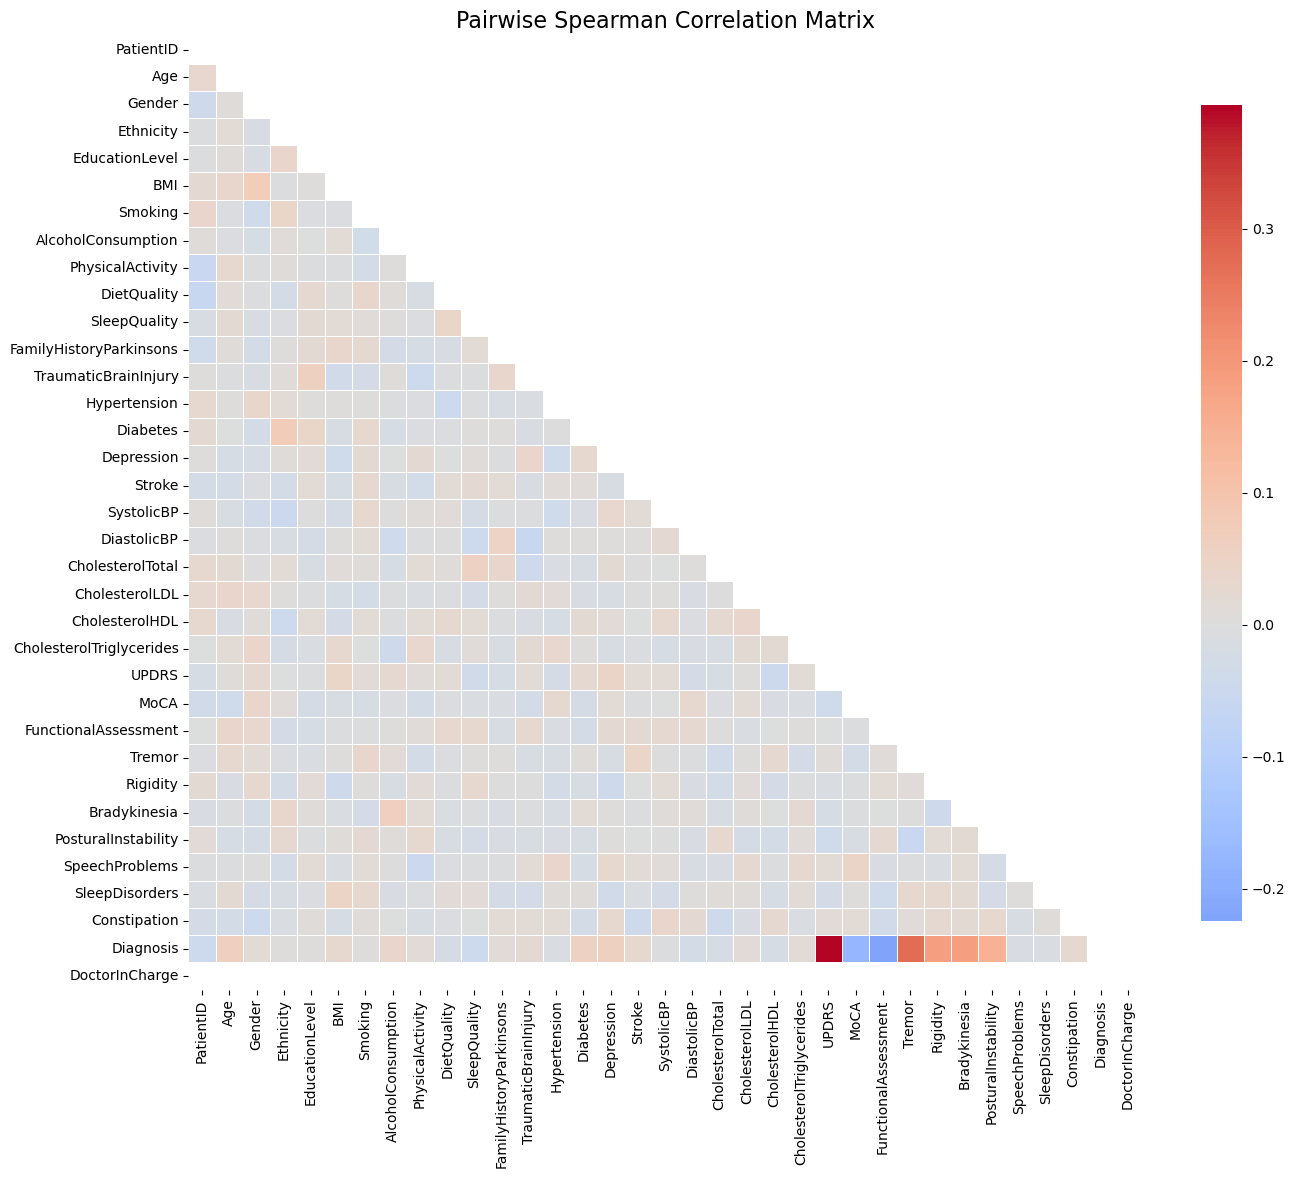

In [44]:
# mask upper triangle (remove duplicates)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

plt.title("Pairwise Spearman Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretation:** 
The correlation matrix also shows that 
- Parkinson’s diagnosis is most strongly associated with higher **UPDRS** scores and motor symptoms such as tremor, rigidity, and bradykinesia,. 
- Cognitive and functional measures (**MoCA** and **FunctionalAssessment**) exhibit negative correlations, indicating worse cognitive and functional status among diagnosed patients, with most other demographic and clinical variables showing weak relationships.
- The correlation matrix confirms that **motor symptoms** and **clinical severity scores** are the strongest predictors of Parkinson’s diagnosis, while most demographic and lifestyle variables show weak relationships and limited predictive influence.

# STEP 4: CHECK CLASS BALANCE (Outcome distribution)

In [47]:
#Check Class Balance
df["Diagnosis"].value_counts(normalize=True)


Diagnosis
1    0.619477
0    0.380523
Name: proportion, dtype: float64

**Interpretation of Class Balance:**
- The class balance check shows that approximately 62% of patients are diagnosed with Parkinson’s disease while about 38% are not, indicating a moderately imbalanced dataset with more positive (diagnosed) cases than negative cases.
- To address class imbalance we will use stratified splitting and class_weight="balanced" in models


# STEP 5: DEFINE FULL MODEL DICTIONARY

To satisfy the project requirement, three SVM models with different kernels were trained; additional models were included for broader comparative analysis.

A dictionary of machine learning models was defined to systematically compare multiple algorithms using consistent parameter settings for training and evaluation within the modeling pipeline.

| Model                   | Works Best When                                                       | Key Strength                                                                        |
| ----------------------- | --------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| **Linear SVM**          | Data is mostly linearly separable                                     | Effective in high-dimensional datasets with simple decision boundaries              |
| **RBF SVM**             | Data has complex nonlinear patterns                                   | Creates flexible decision boundaries for nonlinearly separable data                 |
| **Polynomial SVM**      | Data has moderate nonlinear relationships                             | Captures curved boundaries and feature interactions                                 |
| **Logistic Regression** | Relationships are relatively linear and interpretability is important | Simple, fast, and provides interpretable probability outputs                        |
| **Random Forest**       | Dataset contains mixed variables, noise, and nonlinear relationships  | Handles feature interactions well and reduces overfitting through ensemble learning |
| **XGBoost**             | Structured datasets require high predictive performance               | Sequential boosting improves accuracy by correcting previous errors                 |


In [52]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": svm.SVC(
        kernel="linear",
        C=1,
        class_weight="balanced",
        random_state=42
    ),

    "RBF SVM": svm.SVC(
        kernel="rbf",
        C=1,
        gamma=0.5,
        class_weight="balanced",
        random_state=42
    ),

    "Polynomial SVM": svm.SVC(
        kernel="poly",
        C=1,
        degree=3,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}



# STEP 6: FEATURE SELECTION 


## 6a. Drop features not needed for model prediction
The variables PatientID and DoctorInCharge were removed from the dataset because they do not provide meaningful predictive information for Parkinson’s disease.

In [56]:
df_new=df.drop(columns=["PatientID", "DoctorInCharge"])

df_new.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
0,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,9.283194,...,29.181289,1.572427,1,0,0,0,0,0,0,0
1,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,5.602470,...,12.332639,4.787551,0,1,0,1,0,1,0,1
2,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,9.929824,...,29.927783,2.130686,1,0,0,0,1,0,1,1
3,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,4.196189,...,21.304268,3.391288,1,1,1,0,0,0,1,1
4,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,9.363925,...,8.336364,3.200969,0,0,0,1,0,1,0,0


## 6a. Drop outcome-related variables and the strong predictor feature. 
Identify predictor variables used for model training.
- Drop outcome-related variables: Since "Diagnosis" is the outcome variable the models aim to predict, it was removed from the feature set so it cannot be used as an input feature.
- Avoid data leakage: "UPDRS" is a clinical severity score strongly associated with Parkinson’s diagnosis; including it as a predictor could allow the model to indirectly infer the outcome rather than learn meaningful patterns from other variables.
- Final predictor set: The remaining variables in feature_cols_31 represent the independent features used to train and evaluate the machine learning models across both data splits.

In [59]:
# Select predictor features (exclude outcome and clinical scores)
feature_cols_31= [col for col in df_new.columns if col not in ["UPDRS", "Diagnosis"]]


## Define predictors and target

In [62]:
X = df_new[feature_cols_31]
y = df_new["Diagnosis"]

# STEP 7. Create a reusable pipeline function
A reusable modeling pipeline was created to
- split the dataset into training and testing sets,
- preserving class balance using stratified sampling
- scale the data (Logistic Regression and SVM)
- train each model, 
- compute performance (accuracy, precision, and recall)

**Model performance was evaluated using accuracy, precision, and recall.** 
- Accuracy measures the proportion of correctly classified observations.
- Precision evaluates the reliability of positive predictions.
- Recall measures the ability of the model to correctly identify true positive cases.
  
| Metric    | Meaning                                                      |
| --------- | ------------------------------------------------------------ |
| Accuracy  | Overall percentage of correctly classified observations      |
| Precision | Among predicted positives, how many are actually positive    |
| Recall    | Among actual positives, how many the model correctly detects |


In the context of Parkinson’s disease prediction, recall is particularly important because failing to identify affected patients could lead to missed diagnoses. 


In [149]:
def run_pipeline(X, y, test_size, split_name, feature_set):
    
    # Split into training and testing (define test_size later)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    # Scale the data for Logistic Regression and SVM¶
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    #Train all models
    results = []

    for name, model in models.items():

        if name in ["Linear SVM","RBF SVM","Polynomial SVM","Logistic Regression"]:
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)

        results.append({
            "Split": split_name,
            "Feature Set": feature_set,
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec
        })

    return pd.DataFrame(results)

## Run Two data splits (80–20 and 70–30):
**Two data splits (80–20 and 70–30) were used to train multiple models and compare their performance (combining project steps 2–5).**

### Run the pipeline for 80–20 split


In [73]:
results_80 = run_pipeline(X, y, 0.20, "80-20", "All Features")

### Run the pipeline for 70–30 split


In [75]:
results_70 = run_pipeline(X, y, 0.30, "70-30", "All Features")

## Compare results across both splits with all features
Model performance was evaluated using accuracy, precision, and recall on the test dataset.

In [77]:
final_results_allfeat = pd.concat([results_80, results_70], ignore_index=True)

final_results_allfeat = final_results_allfeat.sort_values(by="Accuracy", ascending=False)

print(final_results_allfeat)

    Split   Feature Set                Model  Accuracy  Precision    Recall
4   80-20  All Features        Random Forest  0.809976   0.789137  0.946360
10  70-30  All Features        Random Forest  0.806962   0.788462  0.941327
11  70-30  All Features              XGBoost  0.787975   0.795872  0.885204
5   80-20  All Features              XGBoost  0.769596   0.792857  0.850575
6   70-30  All Features  Logistic Regression  0.724684   0.826347  0.704082
7   70-30  All Features           Linear SVM  0.719937   0.813411  0.711735
1   80-20  All Features           Linear SVM  0.717340   0.800847  0.724138
9   70-30  All Features       Polynomial SVM  0.705696   0.797688  0.704082
0   80-20  All Features  Logistic Regression  0.705463   0.804444  0.693487
3   80-20  All Features       Polynomial SVM  0.691211   0.788546  0.685824
8   70-30  All Features              RBF SVM  0.620253   0.620253  1.000000
2   80-20  All Features              RBF SVM  0.619952   0.619952  1.000000


## Best model Summary

In [81]:
best_model_allfeat = final_results_allfeat.iloc[0]

print("\nBest Model Summary")
print("----------------------")
print(f"Split       : {best_model_allfeat['Split']}")
print(f"Feature Set : {best_model_allfeat['Feature Set']}")
print(f"Model       : {best_model_allfeat['Model']}")
print(f"Accuracy    : {best_model_allfeat['Accuracy']:.3f}")
print(f"Precision   : {best_model_allfeat['Precision']:.3f}")
print(f"Recall      : {best_model_allfeat['Recall']:.3f}")


Best Model Summary
----------------------
Split       : 80-20
Feature Set : All Features
Model       : Random Forest
Accuracy    : 0.810
Precision   : 0.789
Recall      : 0.946


**Interpretation of Results and Metrics for all features using 80-20 and 70-30 split :**
- **Random Forest** performed best, achieving the highest accuracy (≈0.81) and very high recall (≈0.94) across both splits, indicating strong overall performance and effective identification of Parkinson’s cases. Its tree-based structure likely performed well because it can capture nonlinear relationships and interactions among clinical and symptom variables.
- **XGBoost** showed the second-best performance, with accuracy around 0.77–0.79 and strong recall, likely due to its boosting approach that improves prediction by correcting previous errors.
- **Logistic Regression** and **Linear SVM** demonstrated moderate performance (accuracy ≈0.70–0.72), suggesting they captured some patterns but were less effective because they assume more linear relationships.
- **Polynomial SVM** performed slightly worse (accuracy <0.71), indicating limited ability to model the dataset’s complexity.
- **RBF SVM** performed poorly (accuracy ≈0.62) despite perfect recall (1.0), suggesting it over-predicted positive cases and generated many false positives.
- **Results were consistent across both splits, indicating stable model performance.**



# STEP 8: FOR BONUS POINTS: TOP FEATURES MODELS
**Feature Importance and Top 10% Feature Selection:**
Random Forest feature importance was used to identify the top 10% most predictive variables.


## Pick and Train the Random Forest model using the same splits used earlier 
- This step trains a Random Forest model on the training data and calculates feature importance scores, which measure how much each variable contributes to the model’s predictive performance. 
- Features with higher importance values have a stronger influence on predicting Parkinson’s disease and are used to identify the top predictive variables for the reduced feature model.
- Random Forest was used to compute feature importance because its tree-based structure can capture complex relationships between variables and provides reliable importance scores indicating how strongly each feature contributes to predicting Parkinson’s diagnosis.

In [106]:
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Train Random Forest on training data
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_fs, y_train_fs)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Compute feature importance
- A Random Forest model was trained to estimate feature importance scores, which were then used to identify the top 10% most predictive variables for subsequent model training and evaluation.
- Feature importance scores were extracted from the trained Random Forest model to identify the most predictive variables contributing to Parkinson’s disease classification.

In [117]:
# Extract feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_fs.columns
).sort_values(ascending=False)

top_n = int(len(feature_importance) * 0.10)
top_features = feature_importance.head(top_n).index


print(feature_importance)


FunctionalAssessment        0.107913
MoCA                        0.092881
Tremor                      0.065683
DietQuality                 0.051293
SleepQuality                0.049026
BMI                         0.048962
CholesterolTotal            0.048718
AlcoholConsumption          0.047188
CholesterolLDL              0.046840
PhysicalActivity            0.046699
Age                         0.046253
CholesterolHDL              0.045120
CholesterolTriglycerides    0.045054
SystolicBP                  0.042525
DiastolicBP                 0.041212
Rigidity                    0.031222
Bradykinesia                0.027497
PosturalInstability         0.020515
EducationLevel              0.014887
Ethnicity                   0.013370
Depression                  0.008550
Gender                      0.006938
Smoking                     0.006912
Constipation                0.006621
SleepDisorders              0.006599
SpeechProblems              0.006566
Hypertension                0.005700
D

## Select the top 10% features using the training model

In [119]:
top_n = int(len(feature_importance) * 0.10)

top_features = feature_importance.head(top_n).index

print("Top Features:", list(top_features))

Top Features: ['FunctionalAssessment', 'MoCA', 'Tremor']


## Feature Importance Plot (Top Features)

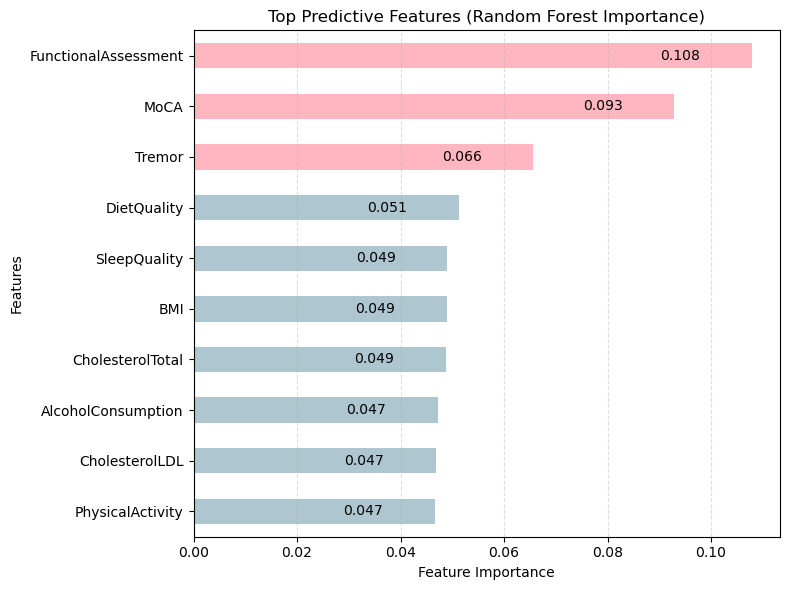

In [121]:
# Get top 10 features
top_features = feature_importance.head(10)

# Sort for horizontal bar chart
top_features_sorted = top_features.sort_values()

# Highlight top 3 features
colors = ["#AEC6CF"] * len(top_features_sorted)  # pastel blue default
for i in range(-3, 0):
    colors[i] = "#FFB6C1"  # pastel pink for top 3

plt.figure(figsize=(8,6))

ax = top_features_sorted.plot(
    kind="barh",
    color=colors
)

plt.title("Top Predictive Features (Random Forest Importance)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# Add numbers inside the bars
for i, v in enumerate(top_features_sorted):
    ax.text(v - 0.01, i, f"{v:.3f}", va="center", ha="right", color="black")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretation: The Random Forest feature importance plot highlights the most influential predictors of Parkinson’s diagnosis, with the three most important features emphasized to clearly illustrate the variables contributing most strongly to model performance.**

## Repeat 80–20 and 70–30 experiments on reduced features

In [123]:

results_80_top = run_pipeline(X_top, y, 0.20, "80-20", "Top 10%")
results_70_top = run_pipeline(X_top, y, 0.30, "70-30", "Top 10%")

## Compare results across both splits for top features

In [125]:
print (results_80_top)

   Split Feature Set                Model  Accuracy  Precision    Recall
0  80-20     Top 10%  Logistic Regression  0.676960   0.785388  0.659004
1  80-20     Top 10%           Linear SVM  0.612827   0.772222  0.532567
2  80-20     Top 10%              RBF SVM  0.724466   0.798354  0.743295
3  80-20     Top 10%       Polynomial SVM  0.624703   0.797688  0.528736
4  80-20     Top 10%        Random Forest  0.722090   0.757143  0.812261
5  80-20     Top 10%              XGBoost  0.724466   0.752613  0.827586


In [127]:
print (results_70_top)

   Split Feature Set                Model  Accuracy  Precision    Recall
0  70-30     Top 10%  Logistic Regression  0.661392   0.774691  0.640306
1  70-30     Top 10%           Linear SVM  0.604430   0.777344  0.507653
2  70-30     Top 10%              RBF SVM  0.715190   0.797753  0.724490
3  70-30     Top 10%       Polynomial SVM  0.620253   0.801587  0.515306
4  70-30     Top 10%        Random Forest  0.713608   0.745921  0.816327
5  70-30     Top 10%              XGBoost  0.707278   0.741259  0.811224


In [129]:
final_results_topfeat = pd.concat([results_80_top, results_70_top], ignore_index=True)

final_results_topfeat = final_results_topfeat.sort_values(by="Accuracy", ascending=False)

print(final_results_topfeat)

    Split Feature Set                Model  Accuracy  Precision    Recall
2   80-20     Top 10%              RBF SVM  0.724466   0.798354  0.743295
5   80-20     Top 10%              XGBoost  0.724466   0.752613  0.827586
4   80-20     Top 10%        Random Forest  0.722090   0.757143  0.812261
8   70-30     Top 10%              RBF SVM  0.715190   0.797753  0.724490
10  70-30     Top 10%        Random Forest  0.713608   0.745921  0.816327
11  70-30     Top 10%              XGBoost  0.707278   0.741259  0.811224
0   80-20     Top 10%  Logistic Regression  0.676960   0.785388  0.659004
6   70-30     Top 10%  Logistic Regression  0.661392   0.774691  0.640306
3   80-20     Top 10%       Polynomial SVM  0.624703   0.797688  0.528736
9   70-30     Top 10%       Polynomial SVM  0.620253   0.801587  0.515306
1   80-20     Top 10%           Linear SVM  0.612827   0.772222  0.532567
7   70-30     Top 10%           Linear SVM  0.604430   0.777344  0.507653


In [131]:
best_model_topfeat = final_results_topfeat.iloc[0]

print("\nBest Top Feature Model Summary")
print("----------------------")
print(f"Split       : {best_model_topfeat['Split']}")
print(f"Feature Set : {best_model_topfeat['Feature Set']}")
print(f"Model       : {best_model_topfeat['Model']}")
print(f"Accuracy    : {best_model_topfeat['Accuracy']:.3f}")
print(f"Precision   : {best_model_topfeat['Precision']:.3f}")
print(f"Recall      : {best_model_topfeat['Recall']:.3f}")


Best Top Feature Model Summary
----------------------
Split       : 80-20
Feature Set : Top 10%
Model       : RBF SVM
Accuracy    : 0.724
Precision   : 0.798
Recall      : 0.743


**Interpretation of Results and Metrics for TOP FEATURES using 80-20 and 70-30 splits:**

- **RBF SVM, Random Forest, and XGBoost**showed the strongest performance, with accuracy around 0.71–0.72 across both splits. These models likely performed well because the reduced feature set retained the most important predictors while still capturing nonlinear relationships.
- **XGBoost and Random Forest** maintained strong recall values (≈0.81–0.83), indicating they remained effective at identifying Parkinson’s cases even with fewer features.
- **RBF SVM** performed better than it did with all features, suggesting that removing less important variables reduced noise and helped the model create better decision boundaries.
- **Logistic Regression** showed moderate performance (accuracy ≈0.66–0.68), indicating that some linear relationships remained useful but overall predictive power decreased with fewer features.
- **Polynomial SVM and Linear SVM** performed the weakest (accuracy ≈0.60–0.62), suggesting they struggled to capture enough complexity after feature reduction.
- **Overall accuracy decreased slightly compared to using all features**, indicating that while the top 10% features retained much of the predictive signal, additional variables in the full dataset still contributed useful information.
- **Results remained consistent across both splits, showing stable model performance.**

**Metric Interpretation:**

- Accuracy measures the overall proportion of correctly classified patients in the dataset.
- Precision indicates how reliable positive predictions are, representing the proportion of predicted Parkinson’s cases that are actually correct.
- Recall measures the model’s ability to correctly identify true Parkinson’s cases and is particularly important in medical prediction tasks to minimize missed diagnoses.

# STEP 9. FINAL RESULTS COMBINED (ALL FEATURES, TOP FEATURES, ALL SPLITS)

In [133]:
final_results_combined = pd.concat(
    [results_80, results_70, results_80_top, results_70_top],
    ignore_index=True
)

final_results_combined = final_results_combined.sort_values(by="Accuracy", ascending=False)

print(final_results_combined)

    Split   Feature Set                Model  Accuracy  Precision    Recall
4   80-20  All Features        Random Forest  0.809976   0.789137  0.946360
10  70-30  All Features        Random Forest  0.806962   0.788462  0.941327
11  70-30  All Features              XGBoost  0.787975   0.795872  0.885204
5   80-20  All Features              XGBoost  0.769596   0.792857  0.850575
6   70-30  All Features  Logistic Regression  0.724684   0.826347  0.704082
14  80-20       Top 10%              RBF SVM  0.724466   0.798354  0.743295
17  80-20       Top 10%              XGBoost  0.724466   0.752613  0.827586
16  80-20       Top 10%        Random Forest  0.722090   0.757143  0.812261
7   70-30  All Features           Linear SVM  0.719937   0.813411  0.711735
1   80-20  All Features           Linear SVM  0.717340   0.800847  0.724138
20  70-30       Top 10%              RBF SVM  0.715190   0.797753  0.724490
22  70-30       Top 10%        Random Forest  0.713608   0.745921  0.816327
23  70-30   

## Overall Model Comparison (All Features + Top 10% Features)
- Random Forest achieved the best overall performance, with the highest accuracy (≈0.81) and recall (≈0.94) when using all features, showing strong ability to identify Parkinson’s cases.
- XGBoost consistently ranked second, performing well across both full-feature and top-feature datasets due to its ability to capture nonlinear relationships.
- Using only the top 10% features slightly reduced overall accuracy (best ≈0.72), but performance remained relatively stable, showing that a smaller set of important variables retained much of the predictive signal.
- RBF SVM improved significantly after feature reduction, suggesting that removing less important variables reduced noise and helped improve model performance.
- Logistic Regression and Linear SVM showed moderate performance, while Polynomial SVM generally performed weaker across both feature sets.
- Overall, tree-based models performed best, suggesting that Parkinson’s diagnosis depends on complex interactions among clinical and symptom variables, and results remained consistent across both train-test splits.

In [136]:
final_results_combined.groupby(["Split","Feature Set"]).first()

Model  Accuracy  Precision    Recall
Split Feature Set                                               
70-30 All Features  Random Forest  0.806962   0.788462  0.941327
      Top 10%             RBF SVM  0.715190   0.797753  0.724490
80-20 All Features  Random Forest  0.809976   0.789137  0.946360
      Top 10%             RBF SVM  0.724466   0.798354  0.743295

### Identify best model out of 24 models

In [143]:
best_model = final_results_combined.iloc[0]

print("\nBest Model Summary")
print("----------------------")
print(f"Split       : {best_model['Split']}")
print(f"Feature Set : {best_model['Feature Set']}")
print(f"Model       : {best_model['Model']}")
print(f"Accuracy    : {best_model['Accuracy']:.3f}")
print(f"Precision   : {best_model['Precision']:.3f}")
print(f"Recall      : {best_model['Recall']:.3f}")


Best Model Summary
----------------------
Split       : 80-20
Feature Set : All Features
Model       : Random Forest
Accuracy    : 0.810
Precision   : 0.789
Recall      : 0.946


**Random Forest achieved the highest predictive performance across both data splits, with accuracy around 0.81 and strong recall values, indicating effective identification of Parkinson’s disease cases. XGBoost performed second best, while SVM models demonstrated moderate performance. When using only the top 10% of predictive features, model performance decreased slightly but remained relatively stable, suggesting that a small subset of variables captures much of the predictive signal in the dataset.**

# VISUALIZATIONS

In [151]:

# Train best model again
best_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix: Random Forest Model")
plt.show()

NameError: name 'X_train' is not defined

**Interpretation of Best Model Confusion Matrix:**
The confusion matrix shows that the Random Forest model correctly identifies most Parkinson’s cases while maintaining relatively few false negatives. This high recall indicates the model is effective at detecting patients with Parkinson’s disease, which is important in medical screening scenarios where missed diagnoses should be minimized.

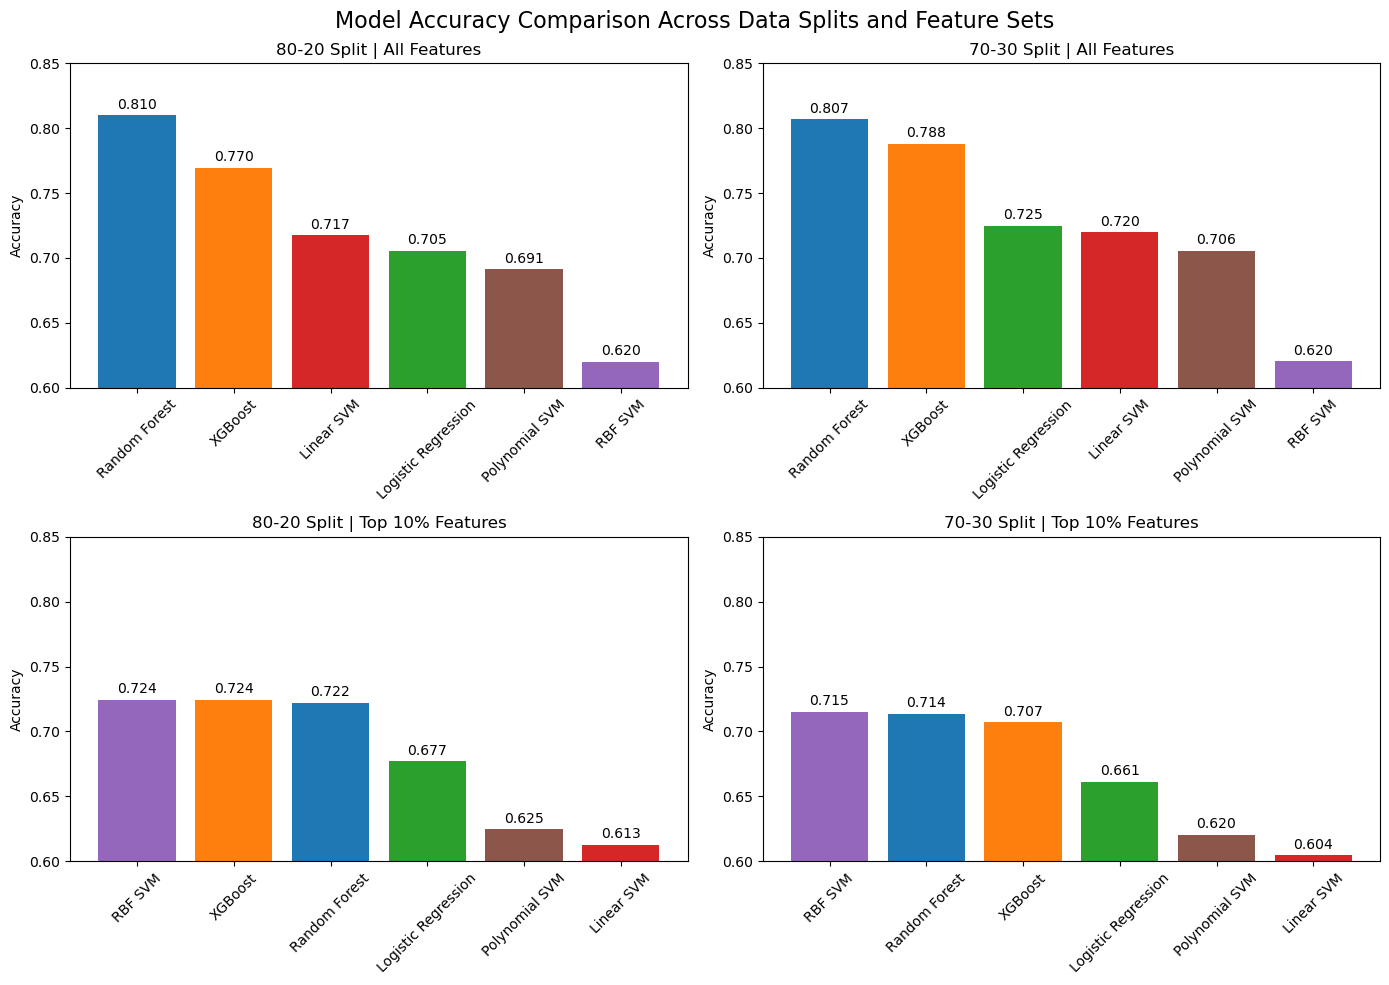

In [790]:
import matplotlib.pyplot as plt

# Define consistent colors for each model
model_colors = {
    "Random Forest": "#1f77b4",
    "XGBoost": "#ff7f0e",
    "Logistic Regression": "#2ca02c",
    "Linear SVM": "#d62728",
    "RBF SVM": "#9467bd",
    "Polynomial SVM": "#8c564b"
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))

def plot_subplot(ax, df, title):
    
    models = df["Model"]
    values = df["Accuracy"]
    
    colors = [model_colors[m] for m in models]
    
    bars = ax.bar(models, values, color=colors)
    
    ax.set_title(title)
    ax.set_ylabel("Accuracy")
    ax.tick_params(axis='x', rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.3f}",
            ha='center'
        )


# 80-20 All
df1 = final_results_combined[
    (final_results_combined["Split"]=="80-20") &
    (final_results_combined["Feature Set"]=="All Features")
].sort_values(by="Accuracy", ascending=False)

plot_subplot(axes[0,0], df1, "80-20 Split | All Features")


# 70-30 All
df2 = final_results_combined[
    (final_results_combined["Split"]=="70-30") &
    (final_results_combined["Feature Set"]=="All Features")
].sort_values(by="Accuracy", ascending=False)

plot_subplot(axes[0,1], df2, "70-30 Split | All Features")


# 80-20 Top10
df3 = final_results_combined[
    (final_results_combined["Split"]=="80-20") &
    (final_results_combined["Feature Set"]=="Top 10%")
].sort_values(by="Accuracy", ascending=False)

plot_subplot(axes[1,0], df3, "80-20 Split | Top 10% Features")


# 70-30 Top10
df4 = final_results_combined[
    (final_results_combined["Split"]=="70-30") &
    (final_results_combined["Feature Set"]=="Top 10%")
].sort_values(by="Accuracy", ascending=False)

plot_subplot(axes[1,1], df4, "70-30 Split | Top 10% Features")


# Same y-scale
for ax in axes.flat:
    ax.set_ylim(0.60,0.85)

plt.suptitle("Model Accuracy Comparison Across Data Splits and Feature Sets", fontsize=16)

plt.tight_layout()

plt.show()

# CONCLUSION
Best model: Random Forest (All Features, 80-20 split) with accuracy = 0.810
- Accuracy ≈ 0.81
- Random Forest detects 95% of Parkinson's cases (Recall : 0.946)
- Slightly lower precision (0.789) means some false positives occur

This project applied multiple machine learning classification models to predict Parkinson’s disease using demographic, clinical, and symptom-related data across two train-test splits (80–20 and 70–30). Among all models, Random Forest achieved the best overall performance, with the highest accuracy (≈0.81) and recall (≈0.94), followed by XGBoost, indicating that tree-based models were most effective at capturing complex relationships within the dataset.

When the analysis was repeated using only the top 10% most predictive features, model accuracy decreased slightly but remained relatively stable, suggesting that a smaller subset of key variables retained much of the predictive information. Overall, the results demonstrate that machine learning models—particularly ensemble tree-based approaches—can effectively support Parkinson’s disease classification using structured healthcare

# References / Dataset source
- Kaggle dataset: Parkinson’s Disease Dataset Analysi.
https://www.kaggle.com/datasets/rabieelkharoua/parkinsons-disease-dataset-analysis?resource=download

**End of Section**